# Chromosome-Specific Enrichment Analysis of Annotations Using Block Jackknife

## Description

Chromosome-specific enrichment analysis for genomic annotations using a block jackknife. For each annotation it computes an odds ratio (OR) and an enrichment statistic, leaving out one chromosome at a time to obtain block-jackknife standard errors. This quantifies how strongly significant variants overlap each annotation relative to the genome.


## Definitions and Test Statistics

### Odds Ratio (OR)
Strength of association between significant variants and an annotation:

$$OR = \frac{\left| AB \right| / \left| A \setminus B \right|}{\left| B \setminus A \right| / \left| \text{noA-noB} \right|}$$

where $A$ = SNPs in the annotation, $B$ = significant SNPs, $AB$ = their intersection, and noA-noB = SNPs in neither.

### Enrichment
Whether an annotation contains a higher proportion of significant SNPs than expected by chance:

$$\text{Enrichment} = \frac{|AB|/|B|}{|A|/|\text{Target Set}|}$$

i.e. proportion of significant SNPs in the annotation divided by proportion of all SNPs in the annotation, where the Target Set is all SNPs in the genome or study region.

### Standard Error (LOCO block jackknife)
Standard errors are estimated by removing one chromosome at a time and recomputing the statistic, capturing variability due to genomic structure. With $\theta_i$ the statistic ($OR_i$ or $\text{Enrichment}_i$) excluding chromosome $i$, $\bar{\theta}$ its mean, and $N$ the number of chromosomes (22 for autosomes):

$$\text{SE}(\theta) = \sqrt{\frac{\sum_{i=1}^{N} (\theta_i - \bar{\theta})^2}{N \cdot (N-1)}}$$


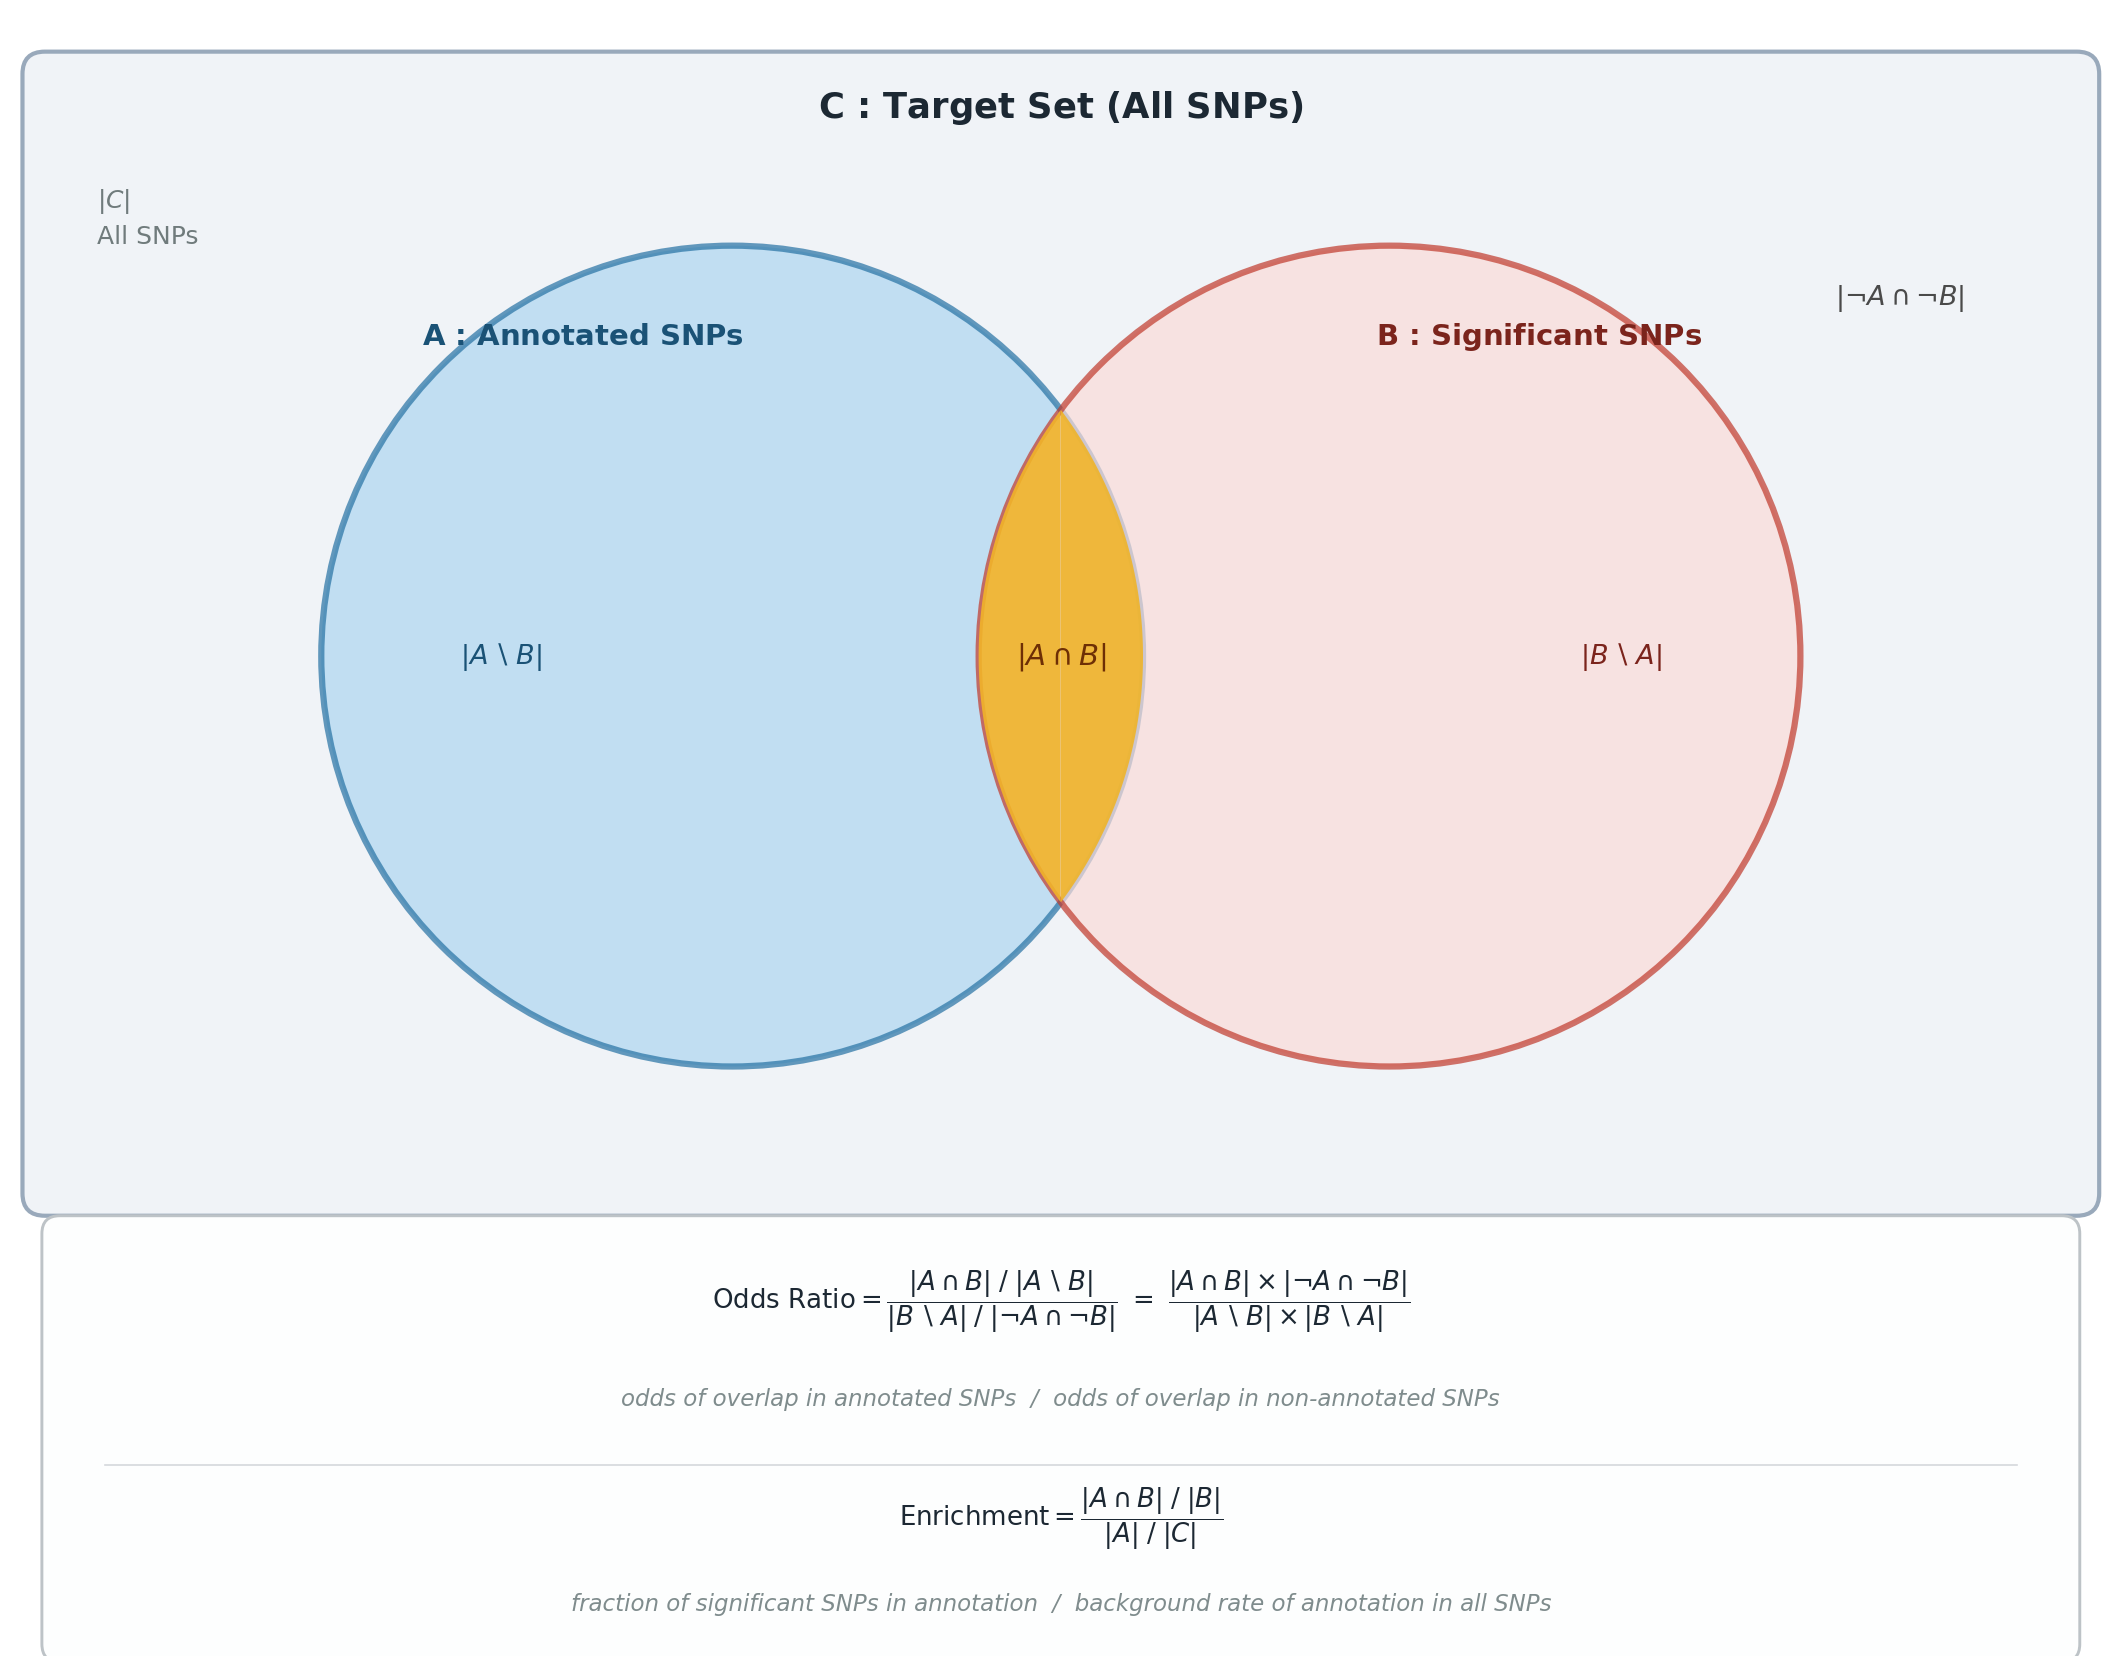

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch, Circle, FancyBboxPatch
from matplotlib.path import Path

def make_lens_path(c1, c2, r, n=400):
    x1, y1 = c1; x2, y2 = c2
    d = np.hypot(x2 - x1, y2 - y1)
    if d >= 2 * r:
        return None
    a   = np.arccos(d / (2 * r))
    phi = np.arctan2(y2 - y1, x2 - x1)
    t1  = np.linspace(phi - a, phi + a, n)
    t2  = np.linspace(phi + np.pi + a, phi + np.pi - a, n)
    verts = (list(zip(x1 + r*np.cos(t1), y1 + r*np.sin(t1))) +
             list(zip(x2 + r*np.cos(t2), y2 + r*np.sin(t2))) +
             [(x1 + r*np.cos(phi - a), y1 + r*np.sin(phi - a))])
    codes = [Path.MOVETO] + [Path.LINETO]*(2*n - 1) + [Path.CLOSEPOLY]
    return Path(verts, codes)

fig, ax = plt.subplots(figsize=(14, 11))
ax.set_xlim(0, 14); ax.set_ylim(0, 11); ax.axis('off')
fig.patch.set_facecolor('white')

# Background box (C)
bg = FancyBboxPatch((0.2, 3.1), 13.6, 7.5, boxstyle='round,pad=0.15',
                    facecolor='#F0F3F7', edgecolor='#99A9BB',
                    linewidth=2.0, zorder=0)
ax.add_patch(bg)

ax.text(7.0, 10.38, r'$\mathbf{C}$ : Target Set (All SNPs)',
        ha='center', va='center', fontsize=17, fontweight='bold', color='#1C2833')
ax.text(0.55, 9.85, r'$|C|$' + '\nAll SNPs',
        ha='left', va='top', fontsize=12, color='#707B7C', linespacing=1.5)

# Circles
cx_a, cy, r = 4.8, 6.7, 2.75
cx_b = 9.2
circ_a = Circle((cx_a, cy), r, facecolor='#AED6F1', edgecolor='#2471A3',
                linewidth=3.0, alpha=0.70, zorder=1)
circ_b = Circle((cx_b, cy), r, facecolor='#FADBD8', edgecolor='#C0392B',
                linewidth=3.0, alpha=0.70, zorder=1)
ax.add_patch(circ_a); ax.add_patch(circ_b)

lens = PathPatch(make_lens_path((cx_a, cy), (cx_b, cy), r),
                 facecolor='#F0B429', edgecolor='none', alpha=0.90, zorder=2)
ax.add_patch(lens)

ax.text(cx_a - 1.0, cy + r*0.78, r'$\mathbf{A}$ : Annotated SNPs',
        ha='center', va='center', fontsize=14, fontweight='bold', color='#1A5276')
ax.text(cx_b + 1.0, cy + r*0.78, r'$\mathbf{B}$ : Significant SNPs',
        ha='center', va='center', fontsize=14, fontweight='bold', color='#7B241C')

mid_x = (cx_a + cx_b) / 2
ax.text(cx_a - 1.55, cy, r'$|A \setminus B|$',
        ha='center', va='center', fontsize=13, color='#1A5276', style='italic')
ax.text(mid_x, cy, r'$|A \cap B|$',
        ha='center', va='center', fontsize=14, fontweight='bold', color='#6E2F05', style='italic')
ax.text(cx_b + 1.55, cy, r'$|B \setminus A|$',
        ha='center', va='center', fontsize=13, color='#7B241C', style='italic')

ax.text(13.05, 9.1, r'$|\neg A \cap \neg B|$',
        ha='right', va='center', fontsize=13, color='#4A4A4A', style='italic')

# Formula box
ax.add_patch(FancyBboxPatch((0.3, 0.08), 13.4, 2.75,
                             boxstyle='round,pad=0.12',
                             facecolor='#FDFEFE', edgecolor='#BDC3C7',
                             linewidth=1.4, zorder=0))

# OR: formula centered, explanation centered below
ax.text(7.0, 2.38,
        r'$\mathrm{Odds\ Ratio} = \dfrac{|A \cap B|\;/\;|A \setminus B|}'
        r'{|B \setminus A|\;/\;|\neg A \cap \neg B|}'
        r'\ =\ \dfrac{|A \cap B| \times |\neg A \cap \neg B|}'
        r'{|A \setminus B| \times |B \setminus A|}$',
        ha='center', va='center', fontsize=12.5, color='#1C2833')
ax.text(7.0, 1.72,
        'odds of overlap in annotated SNPs  /  odds of overlap in non-annotated SNPs',
        ha='center', va='center', fontsize=11, color='#7F8C8D', style='italic')

# Divider
ax.plot([0.6, 13.4], [1.28, 1.28], color='#D5D8DC', linewidth=0.8)

# Enrichment: formula centered, explanation centered below
ax.text(7.0, 0.92,
        r'$\mathrm{Enrichment} = \dfrac{|A \cap B|\;/\;|B|}{|A|\;/\;|C|}$',
        ha='center', va='center', fontsize=12.5, color='#1C2833')
ax.text(7.0, 0.35,
        'fraction of significant SNPs in annotation  /  background rate of annotation in all SNPs',
        ha='center', va='center', fontsize=11, color='#7F8C8D', style='italic')

plt.tight_layout(pad=0.2)
plt.show()

## Input

 1. `significant_variants_path`
- **Format**: RDS file containing significant variants. This must contain some variants that are not in the `baseline_anno_path` input. 
- **Columns**:
  - `chr`: Chromosome number (integer, required).
  - `pos`: Genomic position (integer, required).
- **Example**:
  ```r
  chr  pos
  1    12345
  1    67890

  ```  
2. `baseline_anno_path`

- **Format**: RDS file containing a tabular data frame with baseline annotations. This must contain some variants that are not in the `significant_variants_path` input.
- **Columns**:
    - **CHR**: Chromosome number (integer, required).
    - **BP**: Genomic base pair position (integer, required).
    - **SNP**: SNP ID (character, optional).
    - **CM**: Centimorgan position (numeric, optional).
    - **base**: Base-level information (integer, optional).
    - **Annotation columns**: Binary columns (0/1, required) for various genomic annotations (e.g., `Coding_UCSC`, `Conserved_LindbladToh`, `CTCF_Hoffman`, etc.). Multiple such annnotation columns may exist in the input file. The columns start index of this file is given in the `--annotations-start` argument.
- **Example**:
    
    ```r
    CHR   BP    SNP           CM   base   Coding_UCSC   Coding_UCSC.flanking.500   ⋯   Human_Enhancer_Villar   Human_Enhancer_Villar.flanking.500
    1     11008 rs575272151   0    1      0             0                          ⋯   0                        0
    1     11012 rs544419019   0    1      0             0                          ⋯   0                        0
    1     13110 rs540538026   0    1      0             0                          ⋯   0                        0
    1     13116 rs62635286    0    1      0             0                          ⋯   0                        0
    ```
    



## Output


1. `enrichment_results.rds`

- **Format**: RDS file containing the following components:
    - **`summary`**: A data frame summarizing the OR, OR_SE, Enrichment, and Enrichment_SE for each annotation column.
        
        ```r
        Annotation                      OR      OR_SE   Enrichment   Enrichment_SE
        Coding_UCSC                    1.23    0.12    0.85         0.10
        Conserved_LindbladToh          0.98    0.08    1.12         0.05
        Human_Enhancer_Villar          1.45    0.15    1.30         0.12
        
        ```
        
    - **`OR_blockJacknife`**: A matrix (22 rows for chromosomes × annotation columns) of log2-transformed OR values.
        
        ```r
        Coding_UCSC   Conserved_LindbladToh   Human_Enhancer_Villar
        0.12          -0.02                  0.25
        0.15           0.01                  0.18
        ⋮              ⋮                     ⋮
        ```
        
    - **`Enrichment_blockJacknife`**: A matrix (22 rows for chromosomes × annotation columns) of enrichment values.
    - **`OR`**: A numeric vector of mean log2-transformed OR values across chromosomes for each annotation column.
    - **`Enrichment`**: A numeric vector of mean enrichment values across chromosomes for each annotation column.
    - **`OR_sd`**: A numeric vector of standard errors for OR values across chromosomes for each annotation column.
    - **`Enrichment_sd`**: A numeric vector of standard errors for enrichment values across chromosomes for each annotation column.
    - **`annotations`**: A list of annotation column names.

## Steps


**Step 1.** Run the chromosome-specific enrichment analysis (`enrichment`).

Compares the significant-variant set against the baseline annotation, computing per-annotation odds ratios and enrichment with a 22-chromosome block-jackknife for standard errors. Writes `<name>.enrichment_results.rds` plus a summary `.tsv.gz`.

In [ ]:
sos run pipeline/eoo_enrichment.ipynb enrichment \
    --significant_variants_path input/enrichment/protocol_example.eoo_significant_variants.tsv.gz \
    --baseline_anno_path input/enrichment/protocol_example.eoo_baseline_annotation.tsv \
    --name protocol_example \
    --cwd output/eoo_enrichment

## Anticipated Results

Writes `<annotation>.enrichment_results.rds` (per-annotation OR, Enrichment, and their block-jackknife standard errors) plus a `.tsv.gz` summary. Annotations with a higher proportion of significant variants than expected show OR and Enrichment above 1.


## Command interface

List the workflow and its options:


In [ ]:
sos run pipeline/eoo_enrichment.ipynb -h

## Workflow implementation

In [ ]:
[global]
# Path to the work directory of the analysis.
parameter: cwd = path('output')

parameter: significant_variants_path = path
parameter: baseline_anno_path = path
# Number of threads
parameter: numThreads = 8
# For cluster jobs, number commands to run per job
parameter: name = 'eoo'
parameter: job_size = 1
parameter: walltime = '12h'
parameter: mem = '16G'

In [ ]:
[enrichment]
parameter: annotations_start = 7
output: enrichment = f'{cwd:a}/{step_name}/{name}.enrichment_results.rds'

task: trunk_workers = 1, trunk_size = job_size, walltime = walltime, mem = mem, cores = numThreads, tags = f'{step_name}_{_output[0]:bnn}'
R: expand = '${ }', stderr = f'{_output[0]}.stderr', stdout = f'{_output[0]}.stdout'
    library(tidyverse)

    # Helper function to read different file formats
    read_input_file <- function(file_path) {
        # Get full file extension (e.g., "txt.gz")
        full_ext <- sub(".*\\.", "", file_path)
        # Get base extension (e.g., "txt" from "txt.gz")
        base_ext <- tools::file_ext(sub("\\.gz$", "", file_path))
        
        if (full_ext == "rds") {
            return(readRDS(file_path))
        } else if (base_ext %in% c("txt", "tsv")) {
            return(data.table::fread(file_path))
        } else {
            stop(paste("Unsupported file format:", full_ext))
        }
    }

    calculate_OR_enrichment <- function(set1, set2, target_set = NULL){
        if (is.null(target_set)){
            target_set <- unique(union(set1, set2))
        }
        A <- intersect(set1, target_set)
        B <- intersect(set2, target_set)
        AB <- intersect(A, B)
        AnoB <- setdiff(A, AB)
        noAB <- setdiff(B, AB)
        noAnoB <- setdiff(target_set, c(A,B))
        
        if (length(noAB) == 0 || length(AnoB) == 0) {
            OR <- Enrichment <- 1
        } else {
            OR <- (length(AB) / length(AnoB)) * (length(noAnoB) / length(noAB))
            Den <- length(A) / length(target_set)
            Num <- length(AB) / length(B)
            Enrichment <- Num / Den
        }
        
        return(list("OR" = OR,
                   "Enrichment" = Enrichment))
    }

    # Start timing
    start_time <- Sys.time()
    print(paste("Job started at:", start_time))

    # Load input data
    print("Loading input data...")
    your_anno <- read_input_file("${significant_variants_path}")
    baseline <- read_input_file("${baseline_anno_path}")
    print("Data loaded successfully!")

    if ("chr" %in% colnames(baseline) && !"CHR" %in% colnames(baseline)) {
        names(baseline)[names(baseline) == "chr"] <- "CHR"
    }

    if ("pos" %in% colnames(baseline) && !"BP" %in% colnames(baseline)) {
        names(baseline)[names(baseline) == "pos"] <- "BP"
    }

    if (!is.numeric(baseline$CHR)) {
        baseline$CHR <- as.numeric(gsub("chr", "", baseline$CHR))
    }


    # Process significant variants  
    your_anno <- sapply(1:nrow(your_anno), function(i) {
        a <- your_anno[i,]
        if (is.numeric(a$chr) || grepl("^[0-9]+$", a$chr)) { 
            paste0("chr", a$chr, ":", a$pos)
        } else {
            paste0(a$chr, ":", a$pos)  
        }
    })    
    print("Processed significant variants.")

    # Process baseline annotation
    baseline <- baseline %>%
        mutate(chr_bp = paste0("chr", CHR, ":", BP))%>%
        relocate(chr_bp, .before = 1)

    print("Processed baseline annotation.")

    # Get annotation columns
    annotations_start = ${annotations_start}
    annotations <- colnames(baseline)[annotations_start:ncol(baseline)]
    print(paste("Number of annotations:", length(annotations)))

    # Initialize matrices for results
    OR_blockJacknife <- Enrichment_blockJacknife <- matrix(NA, 
        nrow = 22, 
        ncol = length(annotations))
    colnames(OR_blockJacknife) <- colnames(Enrichment_blockJacknife) <- annotations

    # Perform leave-one-chromosome-out analysis
    print("Starting LOCO analysis...")
    for (i.chr in 1:22){
        chr <- i.chr
        pp <- which(baseline$CHR == chr)
        baseline.jk <- baseline[-pp,]
        target_set <- baseline.jk$chr_bp

        for (i in 1:length(annotations)){
            anno <- baseline %>% select(annotations[i])
            pos <- which(anno == 1)
            baseline.tmp <- baseline$chr_bp[pos]
            res <- calculate_OR_enrichment(baseline.tmp, your_anno, target_set = target_set)
            OR_blockJacknife[i.chr, i] <- res$OR
            Enrichment_blockJacknife[i.chr, i] <- res$Enrichment
        }
        print(paste("Processed chromosome", i.chr, "of 22"))
    }

    # Calculate final statistics
    print("Calculating final statistics...")
    OR <- colMeans(log2(OR_blockJacknife), na.rm = TRUE)
    Enrichment <- colMeans(Enrichment_blockJacknife, na.rm = TRUE)
    Enrichment_log2 <- colMeans(log2(Enrichment_blockJacknife), na.rm = TRUE)

    OR_sd <- Enrichment_sd <- OR_sd_log2 <- Enrichment_sd_log2 <- numeric(length(annotations))
    for (j in 1:length(annotations)){
        OR_sd[j] <- sqrt(var(OR_blockJacknife[,j], na.rm = TRUE) * 21^2 / 22)
        Enrichment_sd[j] <- sqrt(var(Enrichment_blockJacknife[,j], na.rm = TRUE) * 21^2 / 22)
        OR_sd_log2[j] <- sqrt(var(log2(OR_blockJacknife[,j]), na.rm = TRUE) * 21^2 / 22)
        Enrichment_sd_log2[j] <- sqrt(var(log2(Enrichment_blockJacknife[,j]), na.rm = TRUE) * 21^2 / 22)
    }

    # Calculate Z-scores and p-values
    Enrichment_z_scores <- Enrichment / Enrichment_sd
    Enrichment_p_values <- pchisq(Enrichment_z_scores^2, 1, lower.tail = FALSE)
    Enrichment_log2_z_scores <- Enrichment_log2 / Enrichment_sd_log2
    Enrichment_log2_p_values <- pchisq(Enrichment_log2_z_scores^2, 1, lower.tail = FALSE)

    # Create summary data frame
    summary_df <- data.frame(
        Annotation = annotations,
        OR = 2^OR,
        OR_SE = OR_sd,
        OR_log2 = OR,
        OR_SE_log2 = OR_sd_log2,
        Enrichment = Enrichment,
        Enrichment_SE = Enrichment_sd,
        Enrichment_log2 = Enrichment_log2,
        Enrichment_SE_log2 = Enrichment_sd_log2,
        Enrichment_Z_score = Enrichment_z_scores,
        Enrichment_P_value = Enrichment_p_values,
        Enrichment_log2_z_scores = Enrichment_log2_z_scores,
        Enrichment_log2_p_values = Enrichment_log2_p_values        
    )
    print("Summary data frame created.")

    # Prepare results
    results <- list(
        "summary" = summary_df,
        "OR_blockJacknife" = OR_blockJacknife,
        "Enrichment_blockJacknife" = Enrichment_blockJacknife,
        "OR" = OR,
        "Enrichment" = Enrichment,
        "OR_sd" = OR_sd,
        "Enrichment_sd" = Enrichment_sd,
        "Enrichment_Z_scores" = Enrichment_z_scores,
        "Enrichment_P_values" = Enrichment_p_values,                
        "annotations" = annotations
    )
    print("Results prepared.")


    # Save results
    saveRDS(results, '${_output['enrichment']}', compress='xz')
    print(paste("Results saved to:", '${_output['enrichment']}'))

    # Save summary table as TSV gz
    summary_tsv_path <- sub("\\.rds$", "_summary.tsv.gz", '${_output['enrichment']}')
    data.table::fwrite(summary_df, summary_tsv_path, sep="\t", quote=FALSE, compress="gzip")
    print(paste("Summary table saved to:", summary_tsv_path))

    # End timing
    end_time <- Sys.time()
    print(paste("Job ended at:", end_time))
    print(paste("Total time elapsed:", as.numeric(difftime(end_time, start_time, units = "mins")), "minutes"))
